# Uranus Orbit Around the Sun (Two-Body Only)

This notebook simulates Uranus orbiting the Sun with **no other bodies** (strict two-body model).

It uses known Uranus values:
- Mass: $M_U = 8.681\times 10^{25}\,\mathrm{kg}$
- Initial heliocentric position (approx): $(x_0,y_0)=(19.19126393\,\mathrm{AU},0)$
- Initial heliocentric speed (approx): $v_0=6.80\,\mathrm{km/s}$ tangential (+y)

We integrate the equations of motion and check energy/angular-momentum conservation.

## 1) Set Physical Constants and Uranus Initial State

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Physical constants (SI)
G = 6.67430e-11                 # m^3/(kg s^2)
M_sun = 1.98847e30              # kg
M_uranus = 8.6810e25            # kg
mu = G * M_sun

# Unit helpers
AU = 1.495978707e11             # m
day = 24 * 3600                 # s
year = 365.25 * day

# Known Uranus initial state (approx heliocentric)
r0 = np.array([19.19126393 * AU, 0.0], dtype=float)   # m
v0 = np.array([0.0, 6.80e3], dtype=float)             # m/s (tangential)

# Simulation settings
n_years = 200                         # >= 1 Uranus period (~84 years)
dt = 0.5 * day
n_steps = int(np.floor((n_years * year) / dt))

t0 = 0.0
t_end = n_steps * dt

print(f"Uranus mass: {M_uranus:.4e} kg")
print(f"Initial radius: {np.linalg.norm(r0)/AU:.6f} AU")
print(f"Initial speed: {np.linalg.norm(v0)/1e3:.3f} km/s")
print(f"Sim duration: {n_years} years with max_step={dt/day:.2f} days")

Uranus mass: 8.6810e+25 kg
Initial radius: 19.191264 AU
Initial speed: 6.800 km/s
Sim duration: 200 years with max_step=0.50 days


## 2) Implement Gravitational Dynamics (Sun + Uranus Only)

We use
$$
\mathbf{a}(\mathbf{r}) = -\frac{GM_\odot}{\|\mathbf{r}\|^3}\,\mathbf{r}
$$
with the Sun fixed at the origin.

In [2]:
def acceleration_sun_only(r_vec, mu):
    """Heliocentric acceleration due only to the Sun."""
    r = np.linalg.norm(r_vec)
    return -mu * r_vec / r**3

## 3) Add a Numerical Integrator

Using **adaptive RK45** (`solve_ivp`) for orbital integration.

In [12]:
def rhs_sun_only(t_var, state, mu):
    """RHS for Sun-Uranus two-body dynamics."""
    x, y, vx, vy = state
    r = np.sqrt(x**2 + y**2)
    ax = -mu * x / r**3
    ay = -mu * y / r**3
    return [vx, vy, ax, ay]


def integrate_rk45_sun_only(r0, v0, t_end, max_step, mu, rtol=1e-10, atol=1e-13):
    """Adaptive RK45 integration for Sun + Uranus only."""
    y0 = np.array([r0[0], r0[1], v0[0], v0[1]], dtype=float)
    sol = solve_ivp(
        fun=lambda t_var, y_var: rhs_sun_only(t_var, y_var, mu),
        t_span=(0.0, t_end),
        y0=y0,
        method='RK45',
        rtol=rtol,
        atol=atol,
        max_step=max_step,
        dense_output=False
    )
    return sol

## 4) Run the Simulation for Multiple Time Steps

In [13]:
sol_1b = integrate_rk45_sun_only(r0, v0, t_end, dt, mu)

t = sol_1b.t
x = sol_1b.y[0]
y = sol_1b.y[1]
vx = sol_1b.y[2]
vy = sol_1b.y[3]

r_vec = np.column_stack((x, y))
v_vec = np.column_stack((vx, vy))
r = np.linalg.norm(r_vec, axis=1)
speed = np.linalg.norm(v_vec, axis=1)

print(f"Integration finished (RK45). Samples: {len(t)}")
print(f"Simulated time: {t[-1]/year:.2f} years")
print(f"Solver steps accepted: {len(t)}")

Integration finished (RK45). Samples: 146113
Simulated time: 200.00 years
Solver steps accepted: 146113


## 5) Validate Orbital Behavior with Diagnostics

In [14]:
# Specific mechanical energy (per unit mass)
eps = 0.5 * speed**2 - mu / r

eps0 = eps[0]
eps_rel = (eps - eps0) / abs(eps0)

# Specific angular momentum (z-component for 2D)
h = x * vy - y * vx
h0 = h[0]
h_rel = (h - h0) / abs(h0)

# Perihelion/aphelion estimates
r_min = np.min(r)
r_max = np.max(r)
e_est = (r_max - r_min) / (r_max + r_min)

a_est = 0.5 * (r_min + r_max)
T_est = 2 * np.pi * np.sqrt(a_est**3 / mu)

print(f"Perihelion estimate: {r_min/AU:.6f} AU")
print(f"Aphelion estimate:   {r_max/AU:.6f} AU")
print(f"Estimated e:         {e_est:.6f}")
print(f"Estimated period:    {T_est/year:.3f} years")
print(f"Max |Δε/ε0|:         {np.max(np.abs(eps_rel)):.3e}")
print(f"Max |Δh/h0|:         {np.max(np.abs(h_rel)):.3e}")

Perihelion estimate: 19.191264 AU
Aphelion estimate:   19.202055 AU
Estimated e:         0.000281
Estimated period:    84.109 years
Max |Δε/ε0|:         7.513e-14
Max |Δh/h0|:         3.749e-14


## 6) Plot Orbit and Kinematic Time Series

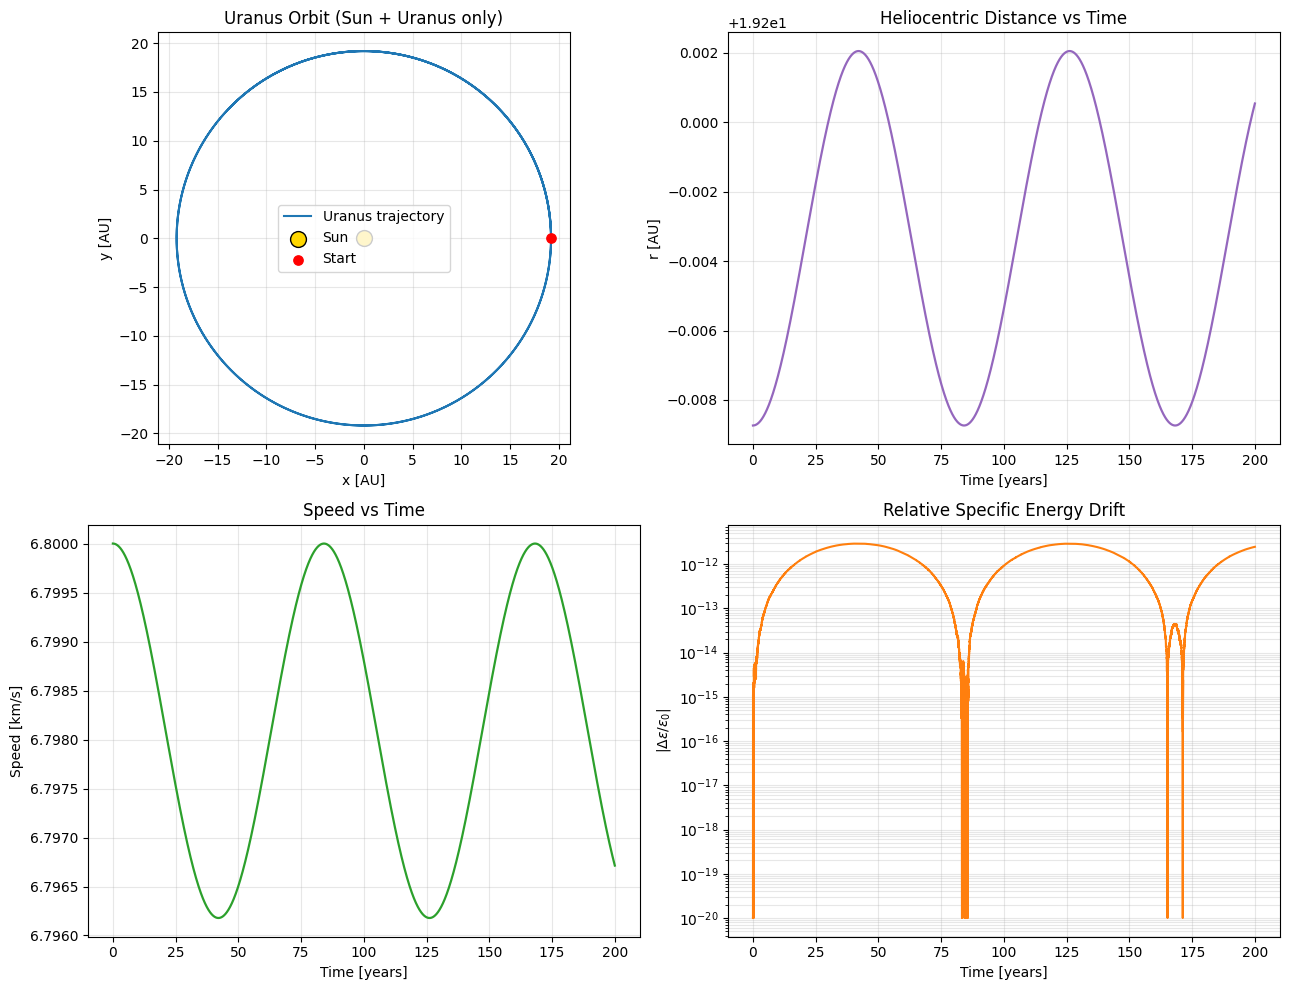

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Orbit plot
axes[0, 0].plot(x / AU, y / AU, lw=1.5, color='tab:blue', label='Uranus trajectory')
axes[0, 0].scatter([0], [0], color='gold', edgecolor='k', s=130, zorder=5, label='Sun')
axes[0, 0].scatter([x[0]/AU], [y[0]/AU], color='red', s=45, zorder=6, label='Start')
axes[0, 0].set_aspect('equal', adjustable='box')
axes[0, 0].set_xlabel('x [AU]')
axes[0, 0].set_ylabel('y [AU]')
axes[0, 0].set_title('Uranus Orbit (Sun + Uranus only)')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend()

# Radius vs time
axes[0, 1].plot(t / year, r / AU, color='tab:purple', lw=1.6)
axes[0, 1].set_xlabel('Time [years]')
axes[0, 1].set_ylabel('r [AU]')
axes[0, 1].set_title('Heliocentric Distance vs Time')
axes[0, 1].grid(alpha=0.3)

# Speed vs time
axes[1, 0].plot(t / year, speed / 1e3, color='tab:green', lw=1.6)
axes[1, 0].set_xlabel('Time [years]')
axes[1, 0].set_ylabel('Speed [km/s]')
axes[1, 0].set_title('Speed vs Time')
axes[1, 0].grid(alpha=0.3)

# Energy drift
axes[1, 1].semilogy(t / year, np.abs(eps_rel) + 1e-20, color='tab:orange', lw=1.5)
axes[1, 1].set_xlabel('Time [years]')
axes[1, 1].set_ylabel(r'$|\Delta \varepsilon / \varepsilon_0|$')
axes[1, 1].set_title('Relative Specific Energy Drift')
axes[1, 1].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

In [16]:
# Period calculation from simulation data (angle-unwrapping method)
# Robust for near-circular orbits where perihelion detection can be noisy.

theta = np.unwrap(np.arctan2(y, x))
dtheta = theta[-1] - theta[0]
dt_total = t[-1] - t[0]

if dtheta != 0:
    T_mean = 2 * np.pi * dt_total / dtheta

    # Instantaneous angular-speed based spread estimate
    omega_inst = np.gradient(theta, t)
    T_inst = 2 * np.pi / omega_inst
    T_std = np.std(T_inst)

    print(f"Mean orbital period from simulation: {T_mean/year:.6f} years")
    print(f"Spread from instantaneous T(t):      {T_std/day:.4f} days")

    if 'T_est' in globals():
        rel_diff = (T_mean - T_est) / T_est
        print(f"Kepler-based estimate (from a_est): {T_est/year:.6f} years")
        print(f"Relative difference:                {rel_diff:+.3e}")
else:
    print("Unable to compute period: total angular displacement is zero.")

Mean orbital period from simulation: 84.106350 years
Spread from instantaneous T(t):      11.9789 days
Kepler-based estimate (from a_est): 84.108546 years
Relative difference:                -2.611e-05


Coupled simulation complete (Sun fixed).
Uranus:   r_min=19.1837 AU, r_max=19.2086 AU
Neptune*: r_min=30.0384 AU, r_max=30.0745 AU
Min Uranus-Neptune* separation = 10.8748 AU


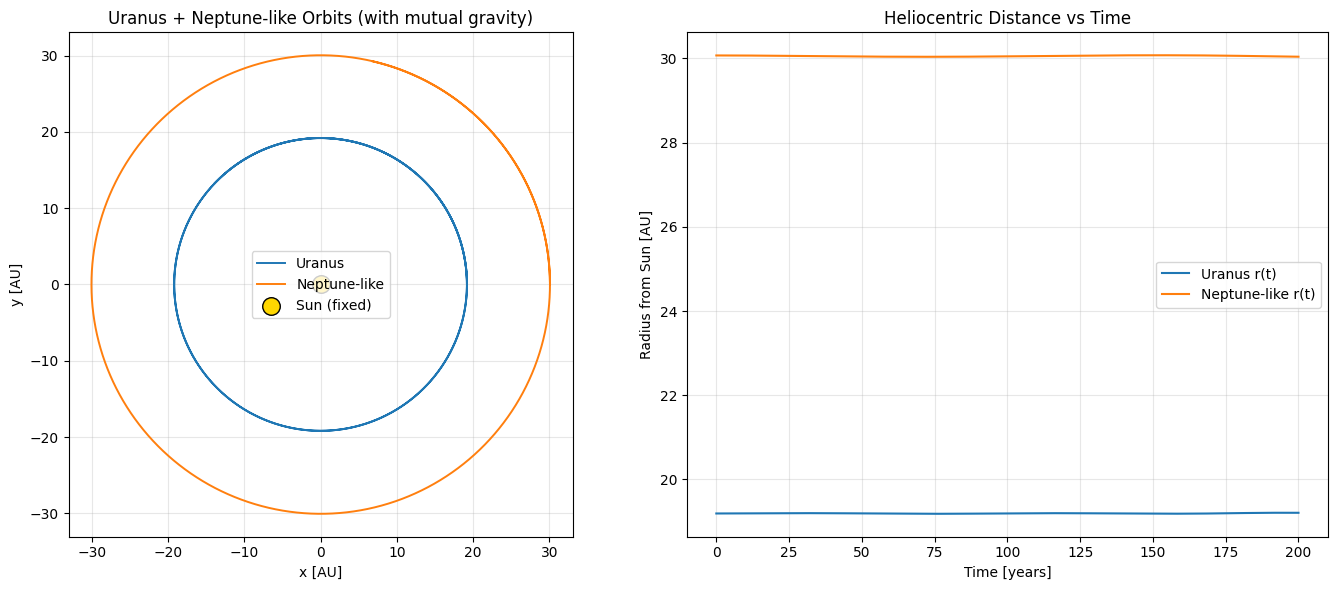

In [ ]:
# Uranus + Neptune-like body with mutual interaction (Sun fixed at origin)
# Sun exerts force on both bodies, and bodies exert force on each other.

# ------------------------------
# Known Neptune values (approx)
# ------------------------------
M_neptune = 1.02413e26                    # kg
r0_neptune = np.array([30.07 * AU, 0.0])  # m
v0_neptune = np.array([0.0, 5.43e3])      # m/s (tangential)

# Reuse Uranus initial state from above (r0, v0, M_uranus)
r0_uranus = r0.copy()
v0_uranus = v0.copy()


def rhs_coupled_rk45(t_var, state, G, M_sun, M_U, M_N):
    """
    State = [xU, yU, vxU, vyU, xN, yN, vxN, vyN]
    Sun fixed at origin; includes mutual Uranus-Neptune gravity.
    """
    xU, yU, vxU, vyU, xN, yN, vxN, vyN = state

    rU = np.array([xU, yU], dtype=float)
    rN = np.array([xN, yN], dtype=float)

    rU_mag = np.linalg.norm(rU)
    rN_mag = np.linalg.norm(rN)

    # Sun contributions
    aU_sun = -G * M_sun * rU / rU_mag**3
    aN_sun = -G * M_sun * rN / rN_mag**3

    # Mutual contributions
    dUN = rN - rU
    dUN_mag = np.linalg.norm(dUN)
    aU_mut =  G * M_N * dUN / dUN_mag**3
    aN_mut = -G * M_U * dUN / dUN_mag**3

    aU = aU_sun + aU_mut
    aN = aN_sun + aN_mut

    return [vxU, vyU, aU[0], aU[1], vxN, vyN, aN[0], aN[1]]


# Run coupled simulation for same duration and max step as above
y0_2b = np.array([
    r0_uranus[0], r0_uranus[1], v0_uranus[0], v0_uranus[1],
    r0_neptune[0], r0_neptune[1], v0_neptune[0], v0_neptune[1]
], dtype=float)

sol_2b = solve_ivp(
    fun=lambda t_var, y_var: rhs_coupled_rk45(t_var, y_var, G, M_sun, M_uranus, M_neptune),
    t_span=(0.0, t_end),
    y0=y0_2b,
    method='RK45',
    rtol=1e-10,
    atol=1e-13,
    max_step=dt,
    dense_output=False
)

t_2b = sol_2b.t
rU_2b = np.column_stack((sol_2b.y[0], sol_2b.y[1]))
vU_2b = np.column_stack((sol_2b.y[2], sol_2b.y[3]))
rN_2b = np.column_stack((sol_2b.y[4], sol_2b.y[5]))
vN_2b = np.column_stack((sol_2b.y[6], sol_2b.y[7]))

# Diagnostics
rU_mag = np.linalg.norm(rU_2b, axis=1)
rN_mag = np.linalg.norm(rN_2b, axis=1)

# Closest approach between Uranus and Neptune-like body
d_UN = np.linalg.norm(rN_2b - rU_2b, axis=1)

print("Coupled simulation complete (RK45, Sun fixed).")
print(f"Uranus:   r_min={np.min(rU_mag)/AU:.4f} AU, r_max={np.max(rU_mag)/AU:.4f} AU")
print(f"Neptune*: r_min={np.min(rN_mag)/AU:.4f} AU, r_max={np.max(rN_mag)/AU:.4f} AU")
print(f"Min Uranus-Neptune* separation = {np.min(d_UN)/AU:.4f} AU")
print(f"Solver steps accepted: {len(t_2b)}")

# Plot
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Orbit view
ax[0].plot(rU_2b[:, 0]/AU, rU_2b[:, 1]/AU, lw=1.4, label='Uranus', color='tab:blue')
ax[0].plot(rN_2b[:, 0]/AU, rN_2b[:, 1]/AU, lw=1.4, label='Neptune-like', color='tab:orange')
ax[0].scatter([0], [0], s=160, color='gold', edgecolor='k', zorder=5, label='Sun (fixed)')
ax[0].set_aspect('equal', adjustable='box')
ax[0].set_xlabel('x [AU]')
ax[0].set_ylabel('y [AU]')
ax[0].set_title('Uranus + Neptune-like Orbits (RK45 with mutual gravity)')
ax[0].grid(alpha=0.3)
ax[0].legend()

# Radius vs time
ax[1].plot(t_2b/year, rU_mag/AU, lw=1.5, color='tab:blue', label='Uranus r(t)')
ax[1].plot(t_2b/year, rN_mag/AU, lw=1.5, color='tab:orange', label='Neptune-like r(t)')
ax[1].set_xlabel('Time [years]')
ax[1].set_ylabel('Radius from Sun [AU]')
ax[1].set_title('Heliocentric Distance vs Time')
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

In [17]:
# Period of Uranus in the coupled (Uranus + Neptune-like) simulation
# and change relative to the previous single-body period.

# Single-body period baseline (recompute directly from Sun-only trajectory)
theta_1b = np.unwrap(np.arctan2(y, x))
dtheta_1b = theta_1b[-1] - theta_1b[0]
T_single = 2 * np.pi * (t[-1] - t[0]) / dtheta_1b if dtheta_1b != 0 else None

# Coupled Uranus period from Uranus trajectory in two-body run
theta_2b = np.unwrap(np.arctan2(rU_2b[:, 1], rU_2b[:, 0]))
dtheta_2b = theta_2b[-1] - theta_2b[0]

if dtheta_2b != 0:
    T_mean_2b = 2 * np.pi * (t_2b[-1] - t_2b[0]) / dtheta_2b

    omega_2b = np.gradient(theta_2b, t_2b)
    T_inst_2b = 2 * np.pi / omega_2b
    T_std_2b = np.std(T_inst_2b)

    print(f"Uranus period (with Neptune-like body): {T_mean_2b/year:.6f} years")
    print(f"Spread from instantaneous T(t):         {T_std_2b/day:.4f} days")

    if T_single is not None:
        dT = T_mean_2b - T_single
        print(f"Previous Uranus period (Sun-only):      {T_single/year:.6f} years")
        print(f"Change ΔT:                              {dT/day:+.4f} days")
        print(f"Relative change ΔT/T:                   {dT/T_single:+.3e}")
else:
    print("Unable to compute coupled period: total angular displacement is zero.")

Uranus period (with Neptune-like body): 84.089172 years
Spread from instantaneous T(t):         20.1382 days
Previous Uranus period (Sun-only):      84.106350 years
Change ΔT:                              -6.2742 days
Relative change ΔT/T:                   -2.042e-04
